In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from skimage.segmentation import active_contour, chan_vese, morphological_chan_vese
from skimage.filters import gaussian

In [46]:
image_paths = sorted(glob.glob("/content/drive/MyDrive/SUIM/TEST/images/*.jpg"))
mask_paths = sorted(glob.glob("/content/drive/MyDrive/SUIM/TEST/masks/*.bmp"))

In [47]:
images = [cv2.imread(p) for p in image_paths]
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]

In [61]:
print(f"Loaded {len(images)} images and {len(masks)} masks")

Loaded 110 images and 110 masks


In [49]:
gray = []
for img in images:
  gray.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))

In [50]:
def compute_metrics(pred, gt):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)

    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou = intersection / union if union != 0 else 0

    dice = (2 * intersection) / (pred_bin.sum() + gt_bin.sum()) if (pred_bin.sum() + gt_bin.sum()) != 0 else 0
    return iou, dice

In [ ]:
def apply_active_contours(img):
    img_norm = img / 255.0
    s = np.linspace(0, 2*np.pi, 400)
    r = img.shape[0]//2 + (img.shape[0]//4)*np.sin(s)
    c = img.shape[1]//2 + (img.shape[1]//4)*np.cos(s)
    init = np.array([r, c]).T
    snake = active_contour(gaussian(img_norm, sigma=3), init, alpha=0.015, beta=10, gamma=0.001)
    mask = np.zeros_like(img)
    pts = snake.astype(np.int32)
    cv2.fillPoly(mask, [pts], 255)
    return mask

In [52]:
def apply_chan_vese(img):
    cv_result = chan_vese(img/255.0, mu=0.25, lambda1=1, lambda2=1, tol=1e-3, dt=0.5)
    return (cv_result.astype(np.uint8)*255)

In [53]:
def apply_level_sets(img):
    ls_result = morphological_chan_vese(img/255.0, num_iter=200, smoothing=3)
    return (ls_result.astype(np.uint8)*255)

In [54]:
results_active, results_chanvese, results_levelsets = [], [], []

for g in gray:
    results_active.append(apply_active_contours(g))
    results_chanvese.append(apply_chan_vese(g))
    results_levelsets.append(apply_level_sets(g))

In [55]:
methods = {
    "Active Contours": results_active,
    "Chan–Vese": results_chanvese,
    "Level Sets": results_levelsets
}

In [56]:
results = {}
for name, preds in methods.items():
    ious, dices = [], []
    for pred, gt in zip(preds, masks):
        iou, dice = compute_metrics(pred, gt)
        ious.append(iou)
        dices.append(dice)
    results[name] = (np.mean(ious), np.mean(dices))

In [60]:
print("\n=== Average metrics on the TEST set ===")
for name, (iou, dice) in results.items():
    print(f"{name:15} → IoU: {iou:.3f}, Dice: {dice:.3f}")


=== Average metrics on the TEST set ===
Active Contours → IoU: 0.119, Dice: 0.203
Chan–Vese       → IoU: 0.462, Dice: 0.605
Level Sets      → IoU: 0.415, Dice: 0.552


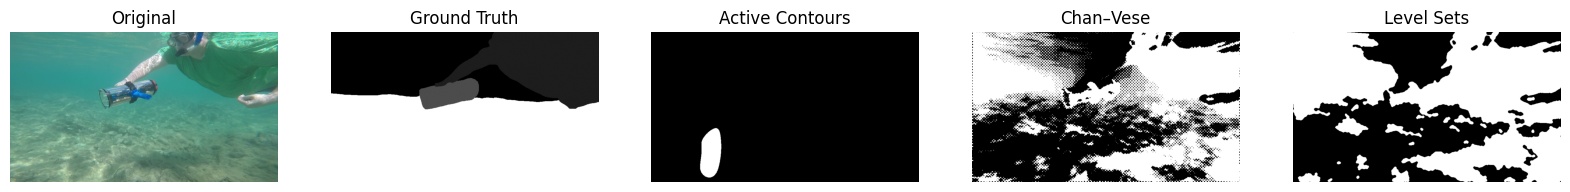

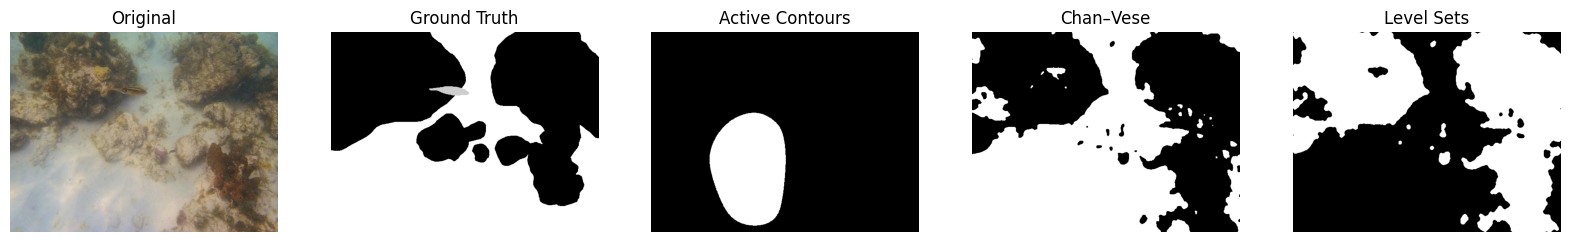

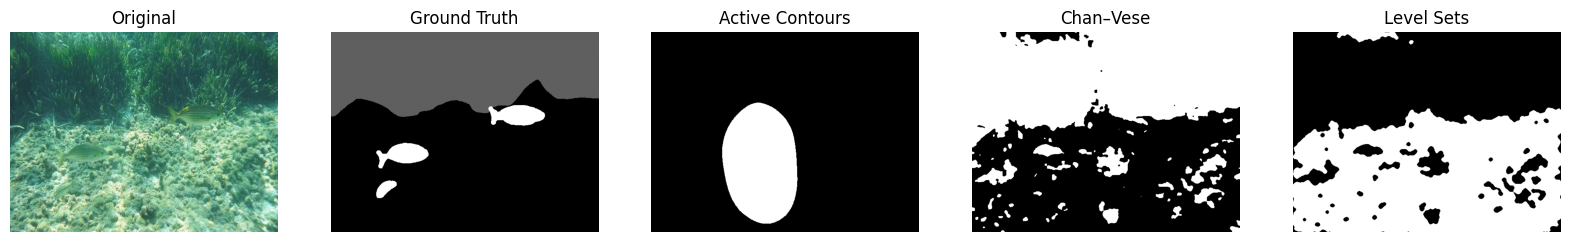

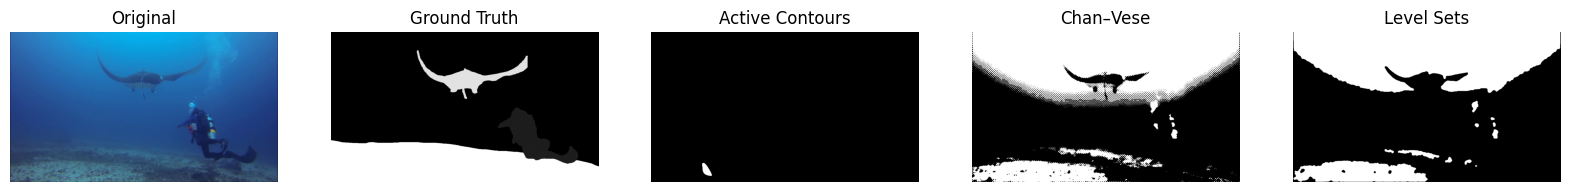

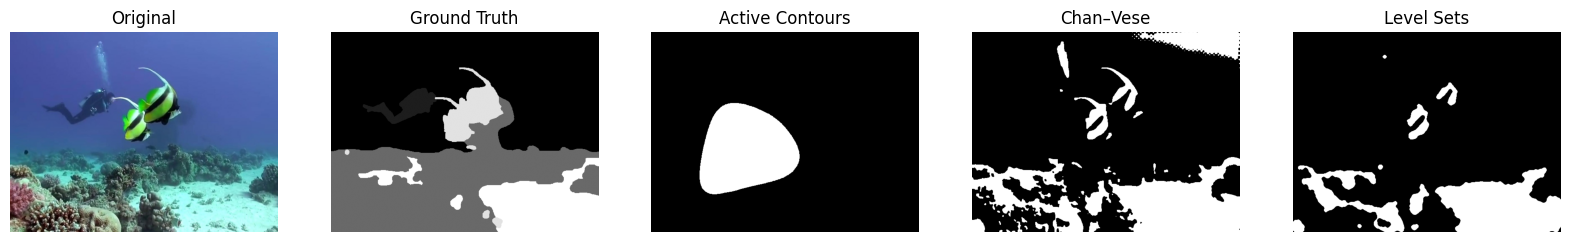

In [58]:
for i in range(5):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20,5))
    plt.subplot(1,5,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
    plt.subplot(1,5,2); plt.imshow(masks[i], cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
    plt.subplot(1,5,3); plt.imshow(results_active[i], cmap="gray"); plt.title("Active Contours"); plt.axis("off")
    plt.subplot(1,5,4); plt.imshow(results_chanvese[i], cmap="gray"); plt.title("Chan–Vese"); plt.axis("off")
    plt.subplot(1,5,5); plt.imshow(results_levelsets[i], cmap="gray"); plt.title("Level Sets"); plt.axis("off")
    plt.show()